In [1]:
import copy
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

sns.set_style('whitegrid')


# 5.i

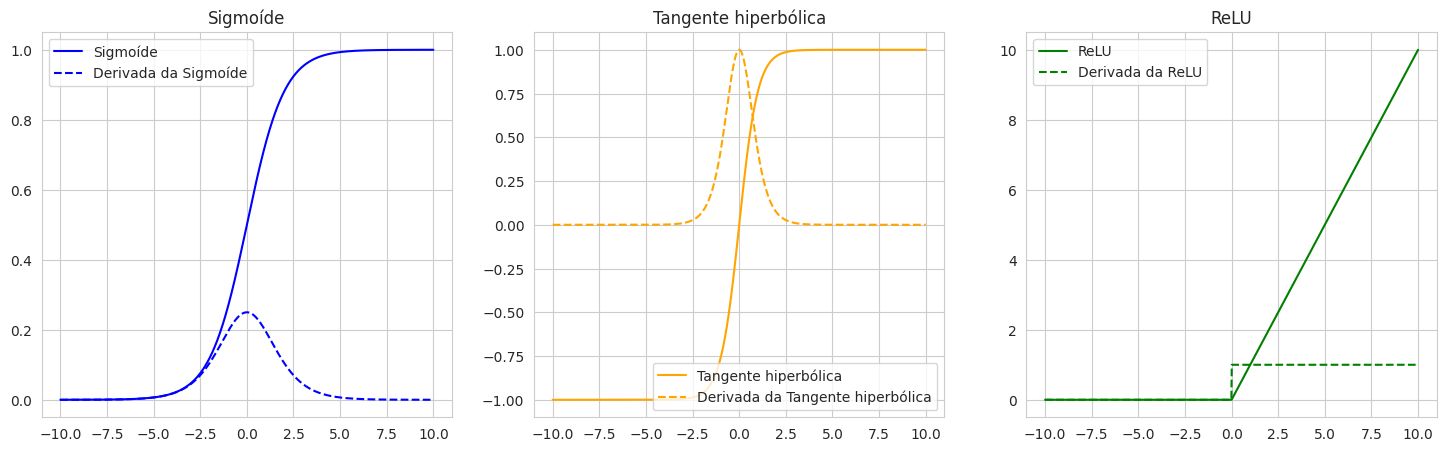

In [29]:
# Plot sigmoid, tanh, and ReLU activation functions (and their respective derivatives):
x = np.linspace(-10, 10, 1000)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

# derivatives
sigmoid_derivative = sigmoid * (1 - sigmoid)
tanh_derivative = 1 - tanh**2
relu_derivative = np.where(x > 0, 1, 0)

# plot it using subplots with the activation functions and their derivatives on the same plot:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sigmoid
axes[0].plot(x, sigmoid, label='Sigmoíde', color='blue')
axes[0].plot(x, sigmoid_derivative, label='Derivada da Sigmoíde', color='blue', linestyle='--')
axes[0].set_title('Sigmoíde')
axes[0].legend()

# Tanh
axes[1].plot(x, tanh, label='Tangente hiperbólica', color='orange')
axes[1].plot(x, tanh_derivative, label='Derivada da Tangente hiperbólica', color='orange', linestyle='--')
axes[1].set_title('Tangente hiperbólica')
axes[1].legend()

# ReLU
axes[2].plot(x, relu, label='ReLU', color='green')
axes[2].plot(x, relu_derivative, label='Derivada da ReLU', color='green', linestyle='--')
axes[2].set_title('ReLU')
axes[2].legend()

plt.show()

# 7. MLPs in Practice

## MLP Setup

To add:
- early stopping 

In [2]:
class MLP(torch.nn.Module):
    """
    Generic Multi-Layer Perceptron (MLP) implementation in PyTorch.
    """
    def __init__(
        self, 
        input_size, 
        hidden_size, 
        n_layers, 
        output_size, 
        is_classifier=False
    ):
        super(MLP, self).__init__()
        
        self.layers = []
        for i in range(n_layers):
            if i == 0:
                self.layers.append(torch.nn.Linear(input_size, hidden_size))
            else:
                self.layers.append(torch.nn.Linear(hidden_size, hidden_size))
            self.layers.append(torch.nn.ReLU())
        self.layers.append(torch.nn.Linear(hidden_size, output_size))
        
        self.fc1 = torch.nn.Sequential(*self.layers[:-1])
        self.fc2 = self.layers[-1]

        if is_classifier:
            if output_size == 1:
                self.softmax = torch.nn.Sigmoid()
            else:
                self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.fc2(out)
        if hasattr(self, 'softmax'):
            out = self.softmax(out)
        return out

In [22]:
from torch.utils.data import TensorDataset, DataLoader

def train(model, x_train, y_train, x_val, y_val, n_epochs=100, learning_rate=0.01, 
          verbose=True, plot=True, patience=10, min_delta=1e-3, batch_size=32):
    
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # --- Create DataLoader for batching ---
    dataset = TensorDataset(x_train, y_train)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    train_losses = []
    val_losses = []
    
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    best_epoch = 0 # Track the actual best epoch
    
    for epoch in range(n_epochs):
        # --- Training Phase ---
        model.train()
        epoch_loss = 0.0
        
        for batch_x, batch_y in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_x.size(0)
            
        epoch_loss /= len(x_train)
        train_losses.append(epoch_loss)

        # --- Validation Phase ---
        model.eval()
        with torch.no_grad():
            val_outputs = model(x_val)
            val_loss = criterion(val_outputs, y_val).item()
            val_losses.append(val_loss)

        if verbose and (epoch + 1) % max(1, (n_epochs // 10)) == 0:
            print(f'Epoch {epoch+1:3d}: Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')

        # --- Early Stopping Logic ---
        if val_loss < (best_loss - min_delta):
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch # Save the exact epoch we found the best weights
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            if verbose:
                print(f'--> Early stopping triggered at epoch {epoch+1}')
            break
    
    # Load the best weights before returning
    model.load_state_dict(best_model_wts)
            
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        
        # Use the tracked best_epoch for accurate plotting
        plt.axvline(x=best_epoch, color='g', linestyle='--', label='Best Model Point')
        
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.show()
    
    return train_losses, val_losses

In [23]:
def find_data_elbow(data_gen_fn, sample_steps=[100, 500, 1000, 5000, 10000], input_size=2):
    results = {}
    for n in sample_steps:
        # Use a fixed, medium-sized model for the test
        model = MLP(input_size=input_size, hidden_size=32, n_layers=2, output_size=1)
        x_train, y_train = data_gen_fn(n)
        x_val, y_val = data_gen_fn(1000) # Keep val size constant for fair comparison
        
        train_losses, val_losses = train(model, x_train, y_train, x_val, y_val, n_epochs=500, verbose=False, plot=False)
        
        model.eval()
        with torch.no_grad():
            val_loss = torch.nn.MSELoss()(model(x_val), y_val).item()
        
        print(f"Samples: {n:5} | Val Loss: {val_loss:.6f}")
        results[n] = val_loss
    return results

In [31]:
def optimize_model_capacity(
    data_gen_fn, 
    train_size=1000, 
    val_size=500, 
    start_hidden=8, 
    max_hidden=256, 
    start_layers=1, 
    max_layers=10,
    rel_tolerance=0.05, 
    abs_tolerance=1e-2,
    n_epochs=1000, 
    learning_rate=0.01,
    is_classifier=False,
    output_size=1,
    input_size=2
):
    """
    Finds the smallest architecture by running a grid search and choosing the most 
    efficient model that performs within a tolerance of the absolute best model.
    Returns: opt_layers, opt_hidden, best_loss, all_histories
    """
    
    print(f"Generating datasets: Train ({train_size}), Val ({val_size})")
    x_train, y_train = data_gen_fn(train_size)
    x_val, y_val = data_gen_fn(val_size)
    
    all_histories = {}
    results = []

    def get_params(layers, hidden):
        # Estimates params for given input_size, output_size
        # Formula: (In*H + H) + (Layers-1)*(H*H + H) + (H*Out + Out)
        return (input_size * hidden + hidden) + (layers - 1) * (hidden * hidden + hidden) + (hidden * output_size + output_size)

    # Generate grid combinations
    hidden_sizes = []
    h = start_hidden
    while h <= max_hidden:
        hidden_sizes.append(h)
        h *= 2
        
    layer_sizes = list(range(start_layers, max_layers + 1))
    
    print("\n--- Starting Grid Search ---")
    best_overall_loss = float('inf')

    for l in layer_sizes:
        for h in hidden_sizes:
            model = MLP(input_size=input_size, hidden_size=h, n_layers=l, output_size=output_size, is_classifier=is_classifier)
            train_h, val_h = train(model, x_train, y_train, x_val, y_val, n_epochs=n_epochs, learning_rate=learning_rate, verbose=False, plot=False)
            
            model.eval()
            with torch.no_grad():
                val_outputs = model(x_val)
                val_loss = torch.nn.MSELoss()(val_outputs, y_val).item()
                
            params = get_params(l, h)
            print(f"Tested [L: {l:2d}, W: {h:3d}] Params: {params:5d} -> Val Loss: {val_loss:.6f}")
            
            all_histories[(l, h)] = val_h
            results.append({'layers': l, 'hidden': h, 'params': params, 'val_loss': val_loss})
            
            if val_loss < best_overall_loss:
                best_overall_loss = val_loss

    # Find the most efficient model within an acceptable loss threshold
    # The threshold allows choosing a smaller model if its loss is close to the absolute best
    loss_threshold = best_overall_loss + max(abs_tolerance, best_overall_loss * rel_tolerance)
    
    print(f"\nGrid search complete. Absolute Best Loss: {best_overall_loss:.6f}")
    print(f"Acceptable Loss Threshold for Efficiency: {loss_threshold:.6f}")
    
    # Filter models that meet the loss threshold
    valid_models = [r for r in results if r['val_loss'] <= loss_threshold]
    
    # Sort valid models by parameter count (ascending) to find the smallest one
    valid_models.sort(key=lambda x: x['params'])
    best_model = valid_models[0]
    
    opt_layers = best_model['layers']
    opt_hidden = best_model['hidden']
    best_loss = best_model['val_loss']

    print("\n" + "="*50)
    print(f"✅ Most Efficient Network: {opt_layers} Layers, {opt_hidden} Hidden Units")
    print(f"Total Parameters: {best_model['params']}, Final Val Loss: {best_loss:.6f}")
    print("="*50)
    
    return opt_layers, opt_hidden, best_loss, all_histories

In [ ]:
def plot_surfaces(model, target_fn, x_range=(-5, 5), grid_n=80, title=""):
    """
    Plot side-by-side 3D surfaces of the analytical target function and
    the network's approximation over a 2D input grid.
    target_fn: callable taking [n, 2] torch tensor -> [n, 1] torch tensor.
    """
    xs = np.linspace(x_range[0], x_range[1], grid_n)
    ys = np.linspace(x_range[0], x_range[1], grid_n)
    XX, YY = np.meshgrid(xs, ys)
    grid = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        Z_true = target_fn(grid).numpy().reshape(XX.shape)
        Z_pred = model(grid).numpy().reshape(XX.shape)

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(XX, YY, Z_true, cmap='viridis', alpha=0.85)
    ax1.set_title(f'{title} — Função real')
    ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('f(x)')

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(XX, YY, Z_pred, cmap='viridis', alpha=0.85)
    ax2.set_title(f'{title} — Aproximação da rede')
    ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel(r'$\hat{y}$')

    plt.tight_layout()
    plt.show()

## 7.1. Equation Regression

### 7.1.a
$f(x) = 16x_1^2 + x_1x_2 + 8x_2^2 - x_1 -x_2 +\ln(1+x_1^2 + x_2^2)$

In [32]:
# Define a data generator for training following f(x) = 16x1^2 + x1x2 + 8x2^2 - x1 -x2 +ln(1+x1^2 + x2^2) where x= [x1, x2]
def data_generator(n_samples):
    x = torch.rand(n_samples, 2)  # Randomly generate n_samples of 2D input
    y = 16 * x[:, 0]**2 + x[:, 0] * x[:, 1] + 8 * x[:, 1]**2 - x[:, 0] - x[:, 1] + torch.log(1 + x[:, 0]**2 + x[:, 1]**2)  # Compute targets using the given function
    return x, y.unsqueeze(1)  # Return inputs and targets as tensors

results = find_data_elbow(data_generator)

Samples:   100 | Val Loss: 0.098678
Samples:   500 | Val Loss: 0.010408
Samples:  1000 | Val Loss: 0.010566
Samples:  5000 | Val Loss: 0.002458
Samples: 10000 | Val Loss: 0.002008


Generating datasets: Train (1000), Val (500)

--- Starting Grid Search ---
Tested [L:  1, W:   4] Params:    17 -> Val Loss: 0.117300
Tested [L:  1, W:   8] Params:    33 -> Val Loss: 0.495044
Tested [L:  1, W:  16] Params:    65 -> Val Loss: 0.080748
Tested [L:  1, W:  32] Params:   129 -> Val Loss: 0.022239
Tested [L:  2, W:   4] Params:    37 -> Val Loss: 1.039462
Tested [L:  2, W:   8] Params:   105 -> Val Loss: 0.033226
Tested [L:  2, W:  16] Params:   337 -> Val Loss: 0.033537
Tested [L:  2, W:  32] Params:  1185 -> Val Loss: 0.006837
Tested [L:  3, W:   4] Params:    57 -> Val Loss: 28.974012
Tested [L:  3, W:   8] Params:   177 -> Val Loss: 0.207660
Tested [L:  3, W:  16] Params:   609 -> Val Loss: 0.018473
Tested [L:  3, W:  32] Params:  2241 -> Val Loss: 0.006932
Tested [L:  4, W:   4] Params:    77 -> Val Loss: 28.975426
Tested [L:  4, W:   8] Params:   249 -> Val Loss: 0.044956
Tested [L:  4, W:  16] Params:   881 -> Val Loss: 0.017868
Tested [L:  4, W:  32] Params:  3297 -

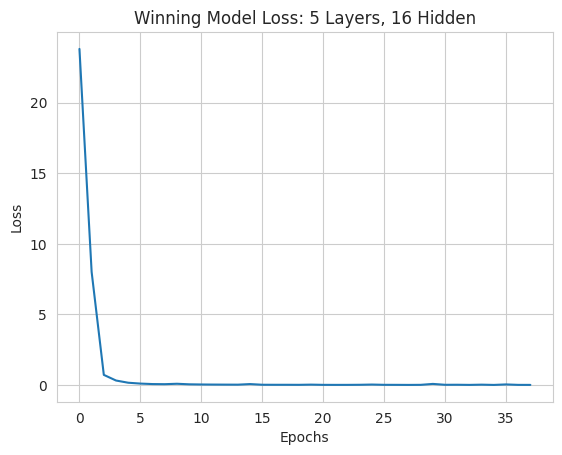

In [26]:
opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    data_generator, 
    train_size=1000, val_size=500, 
    start_hidden=4, max_hidden=32, 
    start_layers=1, max_layers=5,
    rel_tolerance=0.05, n_epochs=200, 
    learning_rate=0.01
)

# Plotting the winning model's loss curve:
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Winning Model Loss: {opt_layers} Layers, {opt_hidden} Hidden")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Train the most efficient architecture from the grid search and compare
# the true target surface against the network's approximation.
def target_fn_71a(x):
    return (16 * x[:, 0]**2 + x[:, 0] * x[:, 1] + 8 * x[:, 1]**2
            - x[:, 0] - x[:, 1]
            + torch.log(1 + x[:, 0]**2 + x[:, 1]**2)).unsqueeze(1)

X_train, y_train = data_generator(2000)
X_val,   y_val   = data_generator(500)

model_71a = MLP(input_size=2, hidden_size=opt_hidden,
                n_layers=opt_layers, output_size=1)
train(model_71a, X_train, y_train, X_val, y_val,
      n_epochs=500, learning_rate=0.01, patience=30, plot=True)

plot_surfaces(model_71a, target_fn_71a, x_range=(0, 1), title="7.1.a")

### 7.1.b

$f(\mathbf{x}) = \frac{1}{2\pi \sqrt{|\mathbf{C}|}} \sum_{i=1}^{3} \exp \left( -\frac{1}{2} (\mathbf{x} - \mathbf{m}_i)^T \mathbf{C} (\mathbf{x} - \mathbf{m}_i) \right)$

In [ ]:
def data_generator(n_samples):
    m1, m2, m3 = [0.0, 0.0], [2.5, 2.5], [-2.5, -2.5]
    c = torch.tensor([[5.0, 0.0], [0.0, 5.0]], dtype=torch.float32)  # inverse covariance matrix
    means = torch.tensor([m1, m2, m3], dtype=torch.float32)

    # Sample over a window large enough to cover the three Gaussian peaks
    x = torch.rand(n_samples, 2) * 10.0 - 5.0
    y = torch.zeros(n_samples, 1)
    for m in means:
        diff = x - m
        quad = (diff @ c * diff).sum(dim=1, keepdim=True)
        y += torch.exp(-0.5 * quad)
    norm = 2 * np.pi * np.sqrt(np.linalg.det(c.numpy()))
    y = y / norm

    return x, y

results = find_data_elbow(data_generator)

Generating datasets: Train (1000), Val (500)

--- Starting Grid Search ---
Tested [L:  1, W:   8] Params:    33 -> Val Loss: 0.000106
Tested [L:  1, W:  16] Params:    65 -> Val Loss: 0.000247
Tested [L:  1, W:  32] Params:   129 -> Val Loss: 0.000115
Tested [L:  1, W:  64] Params:   257 -> Val Loss: 0.000469
Tested [L:  1, W: 128] Params:   513 -> Val Loss: 0.000283
Tested [L:  1, W: 256] Params:  1025 -> Val Loss: 0.000081
Tested [L:  2, W:   8] Params:   105 -> Val Loss: 0.000062
Tested [L:  2, W:  16] Params:   337 -> Val Loss: 0.000121
Tested [L:  2, W:  32] Params:  1185 -> Val Loss: 0.000017
Tested [L:  2, W:  64] Params:  4417 -> Val Loss: 0.000109
Tested [L:  2, W: 128] Params: 17025 -> Val Loss: 0.000048
Tested [L:  2, W: 256] Params: 66817 -> Val Loss: 0.000046
Tested [L:  3, W:   8] Params:   177 -> Val Loss: 0.000567
Tested [L:  3, W:  16] Params:   609 -> Val Loss: 0.000319
Tested [L:  3, W:  32] Params:  2241 -> Val Loss: 0.000014
Tested [L:  3, W:  64] Params:  8577 -> 

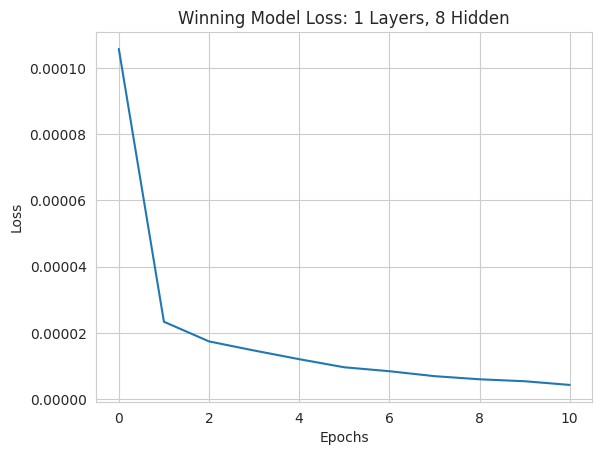

In [28]:
opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    data_generator, 
    train_size=1000, val_size=500, 
    start_hidden=8, max_hidden=256, 
    start_layers=1, max_layers=5,
    rel_tolerance=0.05, n_epochs=200, 
    learning_rate=0.01
)

# Plotting the winning model's loss curve:
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Winning Model Loss: {opt_layers} Layers, {opt_hidden} Hidden")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Train the most efficient architecture from the grid search and compare
# the true target surface against the network's approximation.
def target_fn_71b(x):
    means = torch.tensor([[0.0, 0.0], [2.5, 2.5], [-2.5, -2.5]],
                         dtype=torch.float32)
    c = torch.tensor([[5.0, 0.0], [0.0, 5.0]], dtype=torch.float32)
    y = torch.zeros(x.shape[0], 1)
    for m in means:
        diff = x - m
        quad = (diff @ c * diff).sum(dim=1, keepdim=True)
        y += torch.exp(-0.5 * quad)
    norm = 2 * np.pi * np.sqrt(np.linalg.det(c.numpy()))
    return y / norm

X_train, y_train = data_generator(2000)
X_val,   y_val   = data_generator(500)

model_71b = MLP(input_size=2, hidden_size=opt_hidden,
                n_layers=opt_layers, output_size=1)
train(model_71b, X_train, y_train, X_val, y_val,
      n_epochs=500, learning_rate=0.01, patience=30, plot=True)

plot_surfaces(model_71b, target_fn_71b, x_range=(-5, 5), title="7.1.b")

## 7.2. Binary Spiral Classification

In [ ]:
# Generate points along two interleaved spirals and label them by class.
def data_generator(n_samples):
    n1 = n_samples // 2
    n2 = n_samples - n1

    # Spiral 1: x = (theta/4) cos(theta),  y = (theta/4) sin(theta)
    theta1 = torch.rand(n1) * 4 * np.pi  # theta in [0, 4*pi] for visible spiral arms
    x1 = (theta1 / 4) * torch.cos(theta1)
    y1 = (theta1 / 4) * torch.sin(theta1)

    # Spiral 2: x = (theta/4 + 0.8) cos(theta),  y = (theta/4 + 0.8) sin(theta)
    theta2 = torch.rand(n2) * 4 * np.pi
    x2 = (theta2 / 4 + 0.8) * torch.cos(theta2)
    y2 = (theta2 / 4 + 0.8) * torch.sin(theta2)

    # Combine and label
    x = torch.cat([torch.stack([x1, y1], dim=1), torch.stack([x2, y2], dim=1)], dim=0)
    y = torch.cat([torch.zeros(n1, 1), torch.ones(n2, 1)], dim=0)
    return x, y

# Plot the generated data to visualize the classes:
x, y = data_generator(1000)
plt.figure(figsize=(6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y.squeeze(), cmap='coolwarm', alpha=0.6)
plt.title("Distribuição das duas espirais")
plt.xlabel("x1")
plt.ylabel("x2")
plt.gca().set_aspect('equal')
plt.show()

Generating datasets: Train (1000), Val (500)

--- Starting Grid Search ---
Tested [L:  1, W:   2] Params:     9 -> Val Loss: 0.191348
Tested [L:  1, W:   4] Params:    17 -> Val Loss: 0.123695
Tested [L:  1, W:   8] Params:    33 -> Val Loss: 0.009171
Tested [L:  1, W:  16] Params:    65 -> Val Loss: 0.006736
Tested [L:  1, W:  32] Params:   129 -> Val Loss: 0.006184
Tested [L:  1, W:  64] Params:   257 -> Val Loss: 0.004930
Tested [L:  1, W: 128] Params:   513 -> Val Loss: 0.004463
Tested [L:  1, W: 256] Params:  1025 -> Val Loss: 0.004541
Tested [L:  2, W:   2] Params:    15 -> Val Loss: 0.104751
Tested [L:  2, W:   4] Params:    37 -> Val Loss: 0.005040
Tested [L:  2, W:   8] Params:   105 -> Val Loss: 0.005997
Tested [L:  2, W:  16] Params:   337 -> Val Loss: 0.002530
Tested [L:  2, W:  32] Params:  1185 -> Val Loss: 0.003302
Tested [L:  2, W:  64] Params:  4417 -> Val Loss: 0.001488
Tested [L:  2, W: 128] Params: 17025 -> Val Loss: 0.002638
Tested [L:  2, W: 256] Params: 66817 -> 

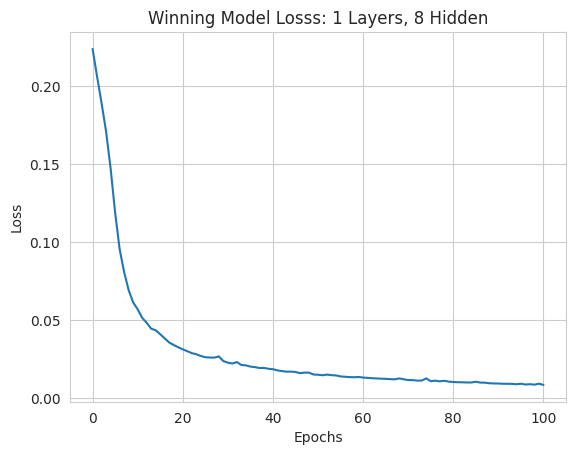

In [34]:
opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    data_generator, 
    train_size=1000, val_size=500, 
    start_hidden=2, max_hidden=256, 
    start_layers=1, max_layers=5,
    rel_tolerance=0.05, n_epochs=200, 
    learning_rate=0.01, is_classifier=True
)

# Plotting the winning model's loss curve:
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Winning Model Losss: {opt_layers} Layers, {opt_hidden} Hidden")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Train the most efficient architecture and compute classification metrics
# on the validation set, including the confusion matrix.
X_train, y_train = data_generator(2000)
X_val,   y_val   = data_generator(500)

model_spirals = MLP(input_size=2, hidden_size=opt_hidden,
                    n_layers=opt_layers, output_size=1, is_classifier=True)
train(model_spirals, X_train, y_train, X_val, y_val,
      n_epochs=500, learning_rate=0.01, patience=30, plot=True)

model_spirals.eval()
with torch.no_grad():
    probs = model_spirals(X_val).numpy().squeeze()
    preds = (probs >= 0.5).astype(int)
    trues = y_val.numpy().squeeze().astype(int)

acc  = accuracy_score(trues, preds)
prec = precision_score(trues, preds, zero_division=0)
rec  = recall_score(trues, preds, zero_division=0)
f1   = f1_score(trues, preds, zero_division=0)

print(f"\n=== Métricas no Conjunto de Validação ===")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(trues, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Espiral 1', 'Espiral 2'],
            yticklabels=['Espiral 1', 'Espiral 2'])
plt.title('Matriz de Confusão — Espirais')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## 7.3. Multi-class Butterfly Classification

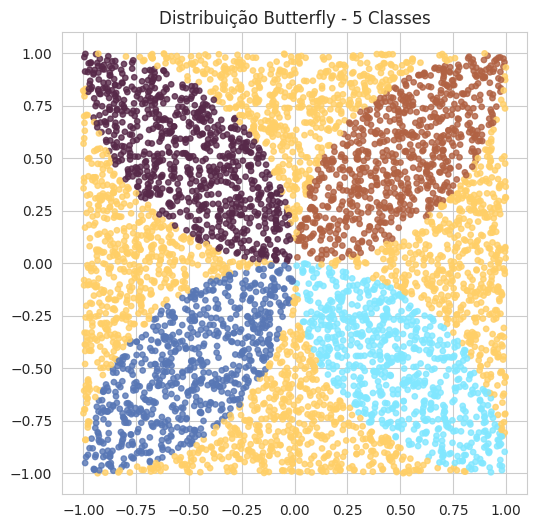

In [35]:

def butterfly_data_generator(n_samples):
    pts = torch.rand(n_samples, 2) * 2 - 1
    x = pts[:, 0]
    y = pts[:, 1]
    
    # Distances to the semicircle centers located at (+1,0), (0,+1), (-1,0), (0,-1)
    d1 = (x - 1)**2 + y**2 <= 1
    d2 = x**2 + (y - 1)**2 <= 1
    d3 = (x + 1)**2 + y**2 <= 1
    d4 = x**2 + (y + 1)**2 <= 1
    
    # Classes defined by the intersection of semicircles and their respective quadrants
    c1 = d1 & d2 & (x > 0) & (y > 0)
    c2 = d2 & d3 & (x < 0) & (y > 0)
    c3 = d3 & d4 & (x < 0) & (y < 0)
    c4 = d4 & d1 & (x > 0) & (y < 0)
    
    # Construction of Label - The 5th class will be formed by the region without intersections (0)
    labels = torch.zeros(n_samples, dtype=torch.long)
    labels[c1] = 1
    labels[c2] = 2
    labels[c3] = 3
    labels[c4] = 4
    
    # One-hot encoding of labels for classification
    y_one_hot = torch.nn.functional.one_hot(labels, num_classes=5).float()
    return pts, y_one_hot

# Visualize the butterfly dataset
X_vis, y_vis = butterfly_data_generator(5000)
plt.figure(figsize=(6,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=torch.argmax(y_vis, dim=1), cmap='managua', s=15, alpha=0.8)
plt.title('Distribuição Butterfly - 5 Classes')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.show()

Generating datasets: Train (2000), Val (500)

--- Starting Grid Search ---
Tested [L:  1, W:   8] Params:    69 -> Val Loss: 0.021290
Tested [L:  1, W:  16] Params:   133 -> Val Loss: 0.015930
Tested [L:  1, W:  32] Params:   261 -> Val Loss: 0.013630
Tested [L:  1, W:  64] Params:   517 -> Val Loss: 0.014338
Tested [L:  1, W: 128] Params:  1029 -> Val Loss: 0.012040
Tested [L:  2, W:   8] Params:   141 -> Val Loss: 0.033576
Tested [L:  2, W:  16] Params:   405 -> Val Loss: 0.017565
Tested [L:  2, W:  32] Params:  1317 -> Val Loss: 0.016886
Tested [L:  2, W:  64] Params:  4677 -> Val Loss: 0.014477
Tested [L:  2, W: 128] Params: 17541 -> Val Loss: 0.015294
Tested [L:  3, W:   8] Params:   213 -> Val Loss: 0.021200
Tested [L:  3, W:  16] Params:   677 -> Val Loss: 0.016596
Tested [L:  3, W:  32] Params:  2373 -> Val Loss: 0.013214
Tested [L:  3, W:  64] Params:  8837 -> Val Loss: 0.028392
Tested [L:  3, W: 128] Params: 34053 -> Val Loss: 0.013856
Tested [L:  4, W:   8] Params:   285 -> 

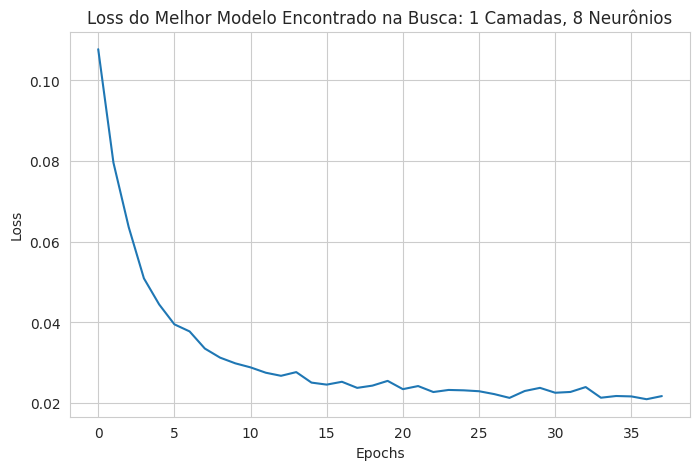

In [38]:
opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    butterfly_data_generator, 
    train_size=2000, val_size=500, 
    start_hidden=8, max_hidden=128, 
    start_layers=1, max_layers=4,
    rel_tolerance=0.05, n_epochs=300, 
    learning_rate=0.01, is_classifier=True, output_size=5
)

# Plotting the winning model's loss curve:
plt.figure(figsize=(8, 5))
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Loss do Melhor Modelo Encontrado na Busca: {opt_layers} Camadas, {opt_hidden} Neurônios")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Epoch  50: Train Loss: 0.0210, Val Loss: 0.0236
Epoch 100: Train Loss: 0.0185, Val Loss: 0.0195
--> Early stopping triggered at epoch 106


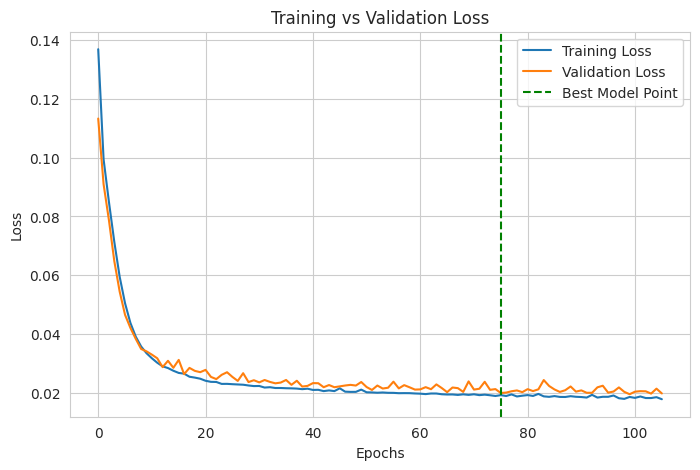


=== Métricas de Desempenho no Conjunto de Validação ===
Acurácia:  0.9330
Precisão:  0.9240
Recall:    0.9490
F1-Score:  0.9355


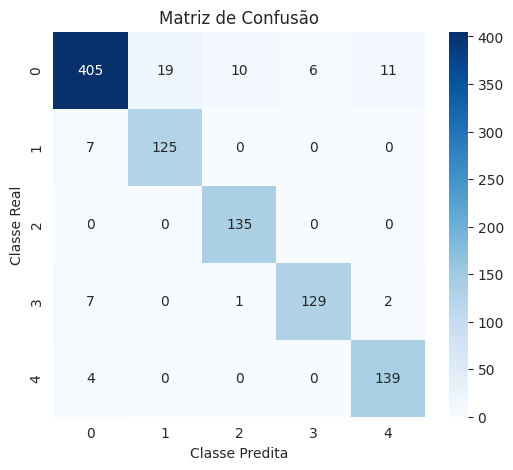

In [39]:
X_train, y_train = butterfly_data_generator(2000)
X_val, y_val = butterfly_data_generator(1000)

# Defining model with the optimal architecture found in the search:
model_butterfly = MLP(input_size=2, hidden_size=opt_hidden, n_layers=opt_layers, output_size=5, is_classifier=True)
train_h, val_h = train(model_butterfly, X_train, y_train, X_val, y_val, 
                       n_epochs=500, learning_rate=0.01, patience=30, plot=True)

model_butterfly.eval()
with torch.no_grad():
    preds_prob = model_butterfly(X_val)
    preds = torch.argmax(preds_prob, dim=1).numpy()
    trues = torch.argmax(y_val, dim=1).numpy()

# Calculating performance metrics
acc = accuracy_score(trues, preds)
prec = precision_score(trues, preds, average='macro', zero_division=0)
rec = recall_score(trues, preds, average='macro', zero_division=0)
f1 = f1_score(trues, preds, average='macro', zero_division=0)

print(f"\n=== Métricas de Desempenho no Conjunto de Validação ===")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

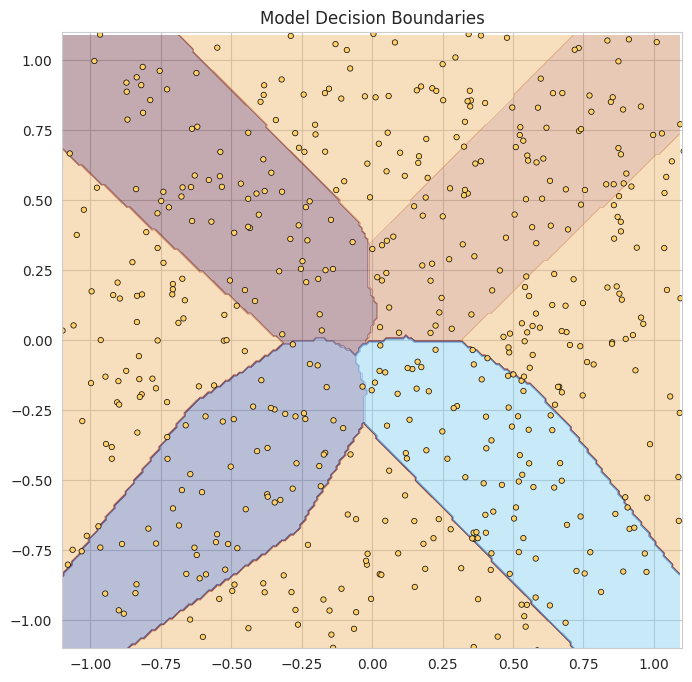

In [49]:
def plot_decision_boundaries(model, x_data, y_data, resolution=0.01):
    """
    Plots the decision boundaries of a trained PyTorch model.
    """
    # 1. Create a meshgrid covering the feature space
    x_min, x_max = -1.1, 1.1
    y_min, y_max = -1.1, 1.1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # Flatten the grid to pass it into the model
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)
    
    # 2. Get model predictions for the entire grid
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        outputs = model(grid_tensor)
        # Get the predicted class (index with highest probability)
        predictions = torch.argmax(outputs, dim=1)
        
    # Reshape the predictions back to the grid shape
    Z = predictions.numpy().reshape(xx.shape)
    
    # 3. Plot the filled contours and the original data points
    plt.figure(figsize=(8, 8))
    
    # Plot the decision regions using the same colormap
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='managua')
    
    # Overlay the actual data points
    y_classes = torch.argmax(y_data, dim=1).numpy()
    plt.scatter(x_data[:, 0].numpy(), x_data[:, 1].numpy(), 
                c=y_classes, cmap='managua', s=15, edgecolor='k', linewidth=0.5)
    
    plt.title("Model Decision Boundaries")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

plot_decision_boundaries(model_butterfly, X_val, y_val)

## 7.4. Time Series Prediction

In [40]:
def time_series_data_generator(n_samples):
    beta = 0.5
    x_mean, x_var = 0.0, 1.5
    v_mean, v_var = 0.0, 1.0

    n_v_samples = n_samples + 2 + 4  # 2 for initial conditions, 4 for the sliding window
    n_x_samples = n_samples + 4  # 4 for the sliding window
    # gaussian noise v (use np random normal and convert to torch tensor)
    v = torch.tensor(np.random.normal(v_mean, np.sqrt(v_var), n_v_samples), dtype=torch.float32)
    # calculate x via sliding window: x[t] = v[t] + beta * v[t-1] * v[t-2] 
    x = torch.zeros(n_x_samples, dtype=torch.float32)
    for t in range(2, n_v_samples):
        x[t - 2] = v[t] + beta * v[t-1] * v[t-2]

    # The training examples will be [x[t-1], x[t-2], x[t-3], x[t-4]] and the target will be x[t]
    X = torch.zeros(n_samples, 4)
    y = torch.zeros(n_samples, 1)
    for i in range(n_samples):
        X[i] = x[i:i+4]
        y[i] = x[i+4]
    return X, y

results = find_data_elbow(time_series_data_generator, input_size=4)

Samples:   100 | Val Loss: 1.213503
Samples:   500 | Val Loss: 1.077533
Samples:  1000 | Val Loss: 1.118638
Samples:  5000 | Val Loss: 1.050188
Samples: 10000 | Val Loss: 1.058686


Generating datasets: Train (5000), Val (1000)

--- Starting Grid Search ---
Tested [L:  1, W:   8] Params:    49 -> Val Loss: 1.030931
Tested [L:  1, W:  16] Params:    97 -> Val Loss: 1.007105
Tested [L:  1, W:  32] Params:   193 -> Val Loss: 1.014710
Tested [L:  1, W:  64] Params:   385 -> Val Loss: 1.005775
Tested [L:  1, W: 128] Params:   769 -> Val Loss: 0.992488
Tested [L:  2, W:   8] Params:   121 -> Val Loss: 1.010890
Tested [L:  2, W:  16] Params:   369 -> Val Loss: 0.995148
Tested [L:  2, W:  32] Params:  1249 -> Val Loss: 0.984955
Tested [L:  2, W:  64] Params:  4545 -> Val Loss: 1.002238
Tested [L:  2, W: 128] Params: 17281 -> Val Loss: 0.996307
Tested [L:  3, W:   8] Params:   193 -> Val Loss: 1.012149
Tested [L:  3, W:  16] Params:   641 -> Val Loss: 0.989193
Tested [L:  3, W:  32] Params:  2305 -> Val Loss: 0.995057
Tested [L:  3, W:  64] Params:  8705 -> Val Loss: 0.995681
Tested [L:  3, W: 128] Params: 33793 -> Val Loss: 0.977793
Tested [L:  4, W:   8] Params:   265 ->

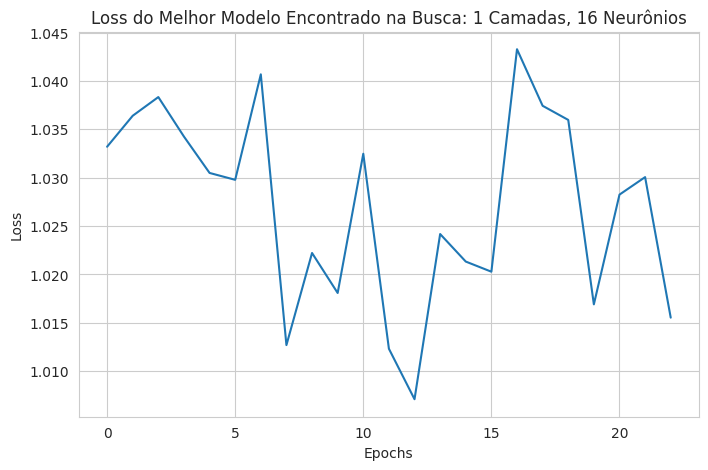

In [56]:
X_train, y_train = time_series_data_generator(5000)
X_val, y_val = time_series_data_generator(1000)

opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    time_series_data_generator, 
    train_size=5000, val_size=1000, 
    start_hidden=8, max_hidden=128, 
    start_layers=1, max_layers=4,
    rel_tolerance=0.05, n_epochs=300, 
    learning_rate=0.01, is_classifier=False, output_size=1,
    input_size=4
)

# Plotting the winning model's loss curve:
plt.figure(figsize=(8, 5))
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Loss do Melhor Modelo Encontrado na Busca: {opt_layers} Camadas, {opt_hidden} Neurônios")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

--> Early stopping triggered at epoch 50


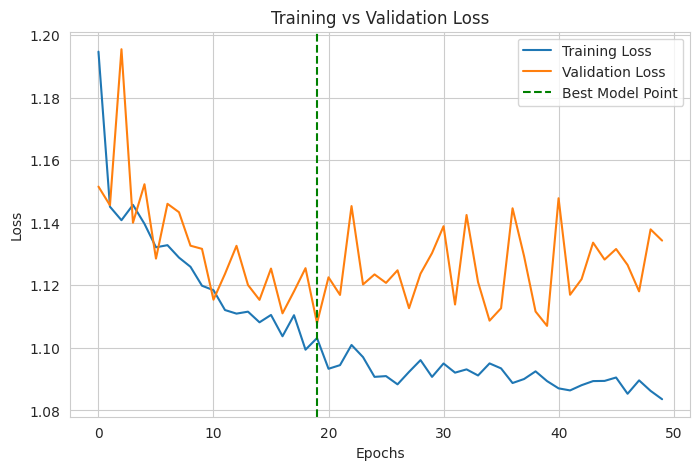

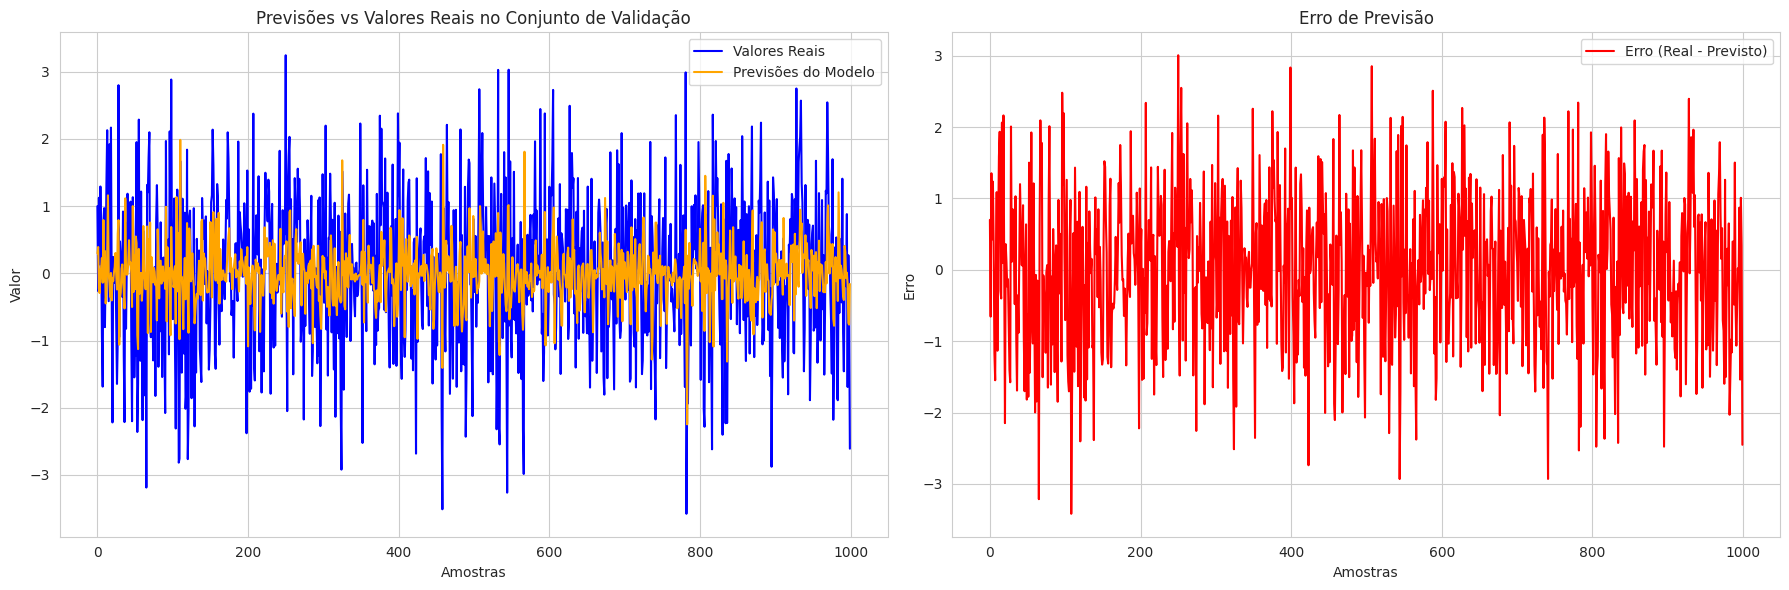

In [57]:
# Train the selected model on the time series data and then plot the predictions vs true values on the validation set:
model_time_series = MLP(input_size=4, hidden_size=opt_hidden, n_layers=opt_layers, output_size=1, is_classifier=False)
train_h, val_h = train(model_time_series, X_train, y_train, X_val, y_val, 
                       n_epochs=1000, learning_rate=0.01, patience=30, plot=True)

model_time_series.eval()
with torch.no_grad():
    preds = model_time_series(X_val).numpy()
    trues = y_val.numpy()

# Plot both time series together and the error plot for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: True vs Predicted
axes[0].plot(trues, label='Valores Reais', color='blue')
axes[0].plot(preds, label='Previsões do Modelo', color='orange')
axes[0].set_title('Previsões vs Valores Reais no Conjunto de Validação')
axes[0].set_xlabel('Amostras')
axes[0].set_ylabel('Valor')
axes[0].legend()

# Right plot: Error
error = trues - preds
axes[1].plot(error, label='Erro (Real - Previsto)', color='red')
axes[1].set_title('Erro de Previsão')
axes[1].set_xlabel('Amostras')
axes[1].set_ylabel('Erro')
axes[1].legend()

plt.tight_layout()
plt.show()